# Titanic Dataset Analysis
## Project Goal

The goal of this notebook is to perform exploratory data analysis using Python libraries such as Pandas and Seaborn. 

This project includes:
- Data Loading
- Data Cleaning
- Exploratory Analysis
- Data Visualization
- Feature Analysis 
- Insights and Conclusions

## Step 1 - Import Libraries 

In [65]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt  

## Step 2 - Load Dataset 
We'll use the Titanic dataset available in Seaborn. 

In [66]:
df = sns.load_dataset('titanic')

## Step 3 - Preview the Dataset
Displaying the first rows to understand the structure. 

In [67]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 4 - Explore Dataset Information 

Checking: 
- number of rows and columns (df.shape)
- column names (df.columns)
- data types (df.dtypes)
- missing values (df.isnull().sum())

In [68]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 5 - Missing Values Analysis

In [69]:
df.isnull().sum()   

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Step 6 - Variable Distribution - Countplot
Analyzing how survival changed depending on passenger gender. 

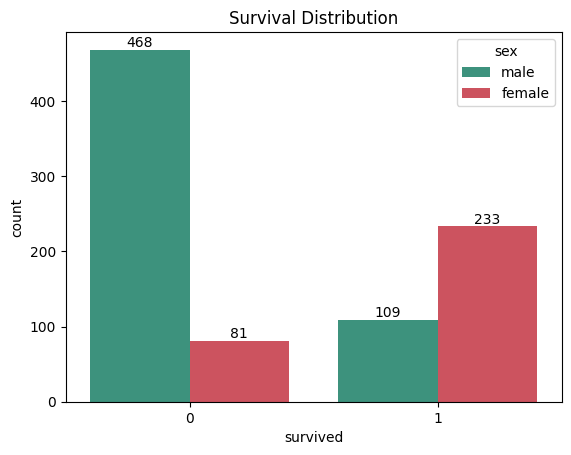

In [70]:
ax = sns.countplot(data=df, x="survived", palette=("#2FA084","#E03F4F"), hue="sex")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Survival Distribution")
plt.show()

### Insights 

- Female passengers had a significantly higher survival rate
- Most male passengers did not survive
- Gender appears to be strongly related to survival probability

## Step 7 - Survival Rate by Passenger Class (Group By)

In [71]:
survival_by_class = df.groupby("class")["survived"].mean().reset_index()

C:\Users\spavone\AppData\Local\Temp\ipykernel_21952\345769106.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class = df.groupby("class")["survived"].mean().reset_index()


C:\Users\spavone\AppData\Local\Temp\ipykernel_21952\2597755293.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_by_class, x="class", y="survived", palette=("#1F6F5F", "#2FA084", "#6FCF97"))


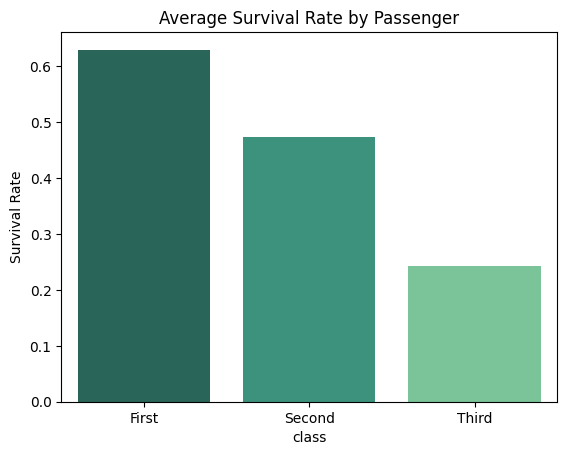

In [72]:
sns.barplot(data=survival_by_class, x="class", y="survived", palette=("#1F6F5F", "#2FA084", "#6FCF97"))
plt.title("Average Survival Rate by Passenger")
plt.ylabel("Survival Rate")
plt.show()


## Step 8 - Missing Values Deeper Analysis

In [73]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

### Insights
- The "deck" column contains many missing values
- "age" algo has missing data that may affect analysis
- Some columns may need cleaning or imputation

## Step 10 - Handle Missing Values 
"age" column will be imputated with median

In [75]:
df["age"] = df["age"].fillna(df["age"].median())

## Step 11 - Verify Cleaning

In [78]:
df["age"].isnull().sum()

np.int64(0)

## Step 11 - Age Distribution Histogram

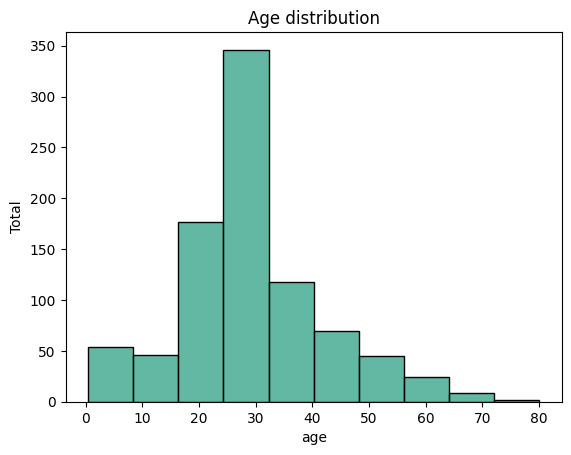

In [82]:
sns.histplot(data=df, x="age", bins=10, color="#2FA084")
plt.title("Age distribution")
plt.ylabel("Total")
plt.show()

## Step 12 - Survival by Age

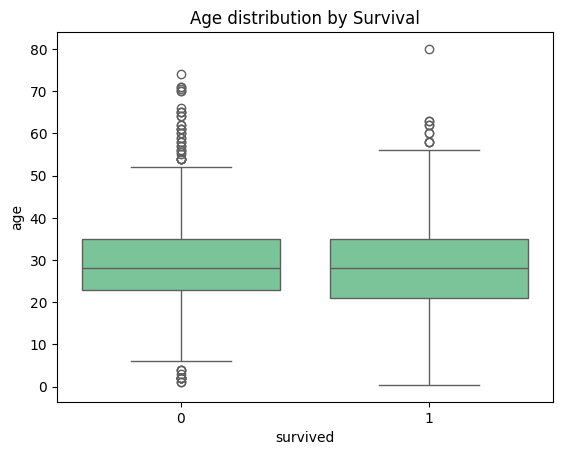

In [85]:
sns.boxplot(data=df, x="survived", y="age", color="#6FCF97")
plt.title("Age distribution by Survival")
plt.show()

## Step 13 - Correlation Heatmap

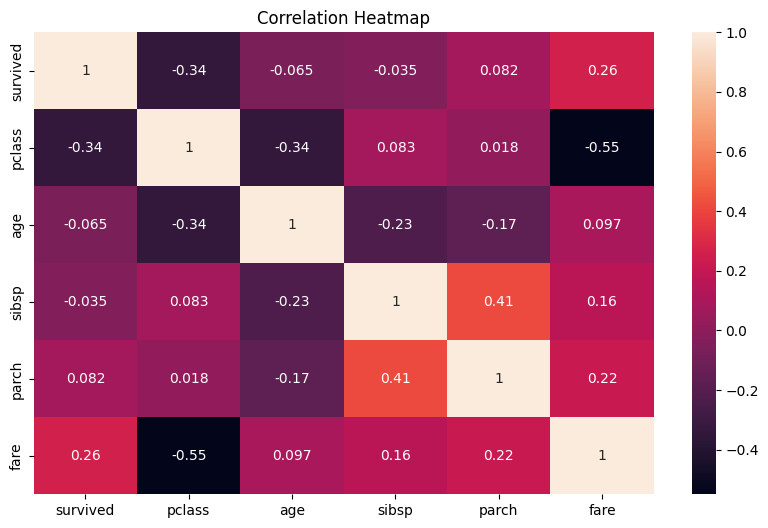

In [ ]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()